# Investigating Performance Anomalies

Some workloads have anomalous steps — most steps are fine, every so often one is 2x, 5x, 50x slower. A fixed-window profiler almost never catches them.

**Pattern: trace every step continuously with CUDA-only activities, flush the buffer every step, and only write to disk when the step exceeds a threshold.** Saved traces are tight — one anomaly = one small trace, no surrounding context.

We walk through this with a ResNet18 example, a synthetic anomaly injector, and the TraceLens perf-report generator. Builds on the [PyTorch profiling guide](./torch_profiling_guide.ipynb).

## 1  Setup

In [1]:
import random
import statistics
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torchvision.models as models
from torch.profiler import profile, ProfilerActivity, schedule

device = "cuda"
dtype = torch.bfloat16
torch.manual_seed(0)
random.seed(0)

model = models.resnet18().to(device).to(dtype)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

B, C, H, W = 5, 3, 224, 224
num_classes = 1000
dummy_input = torch.randn(B, C, H, W, device=device, dtype=dtype)
dummy_target = torch.randn(B, num_classes, device=device, dtype=dtype)

## 2  Anomaly simulator

For a runnable example, `train_step()` does a normal forward/backward/step **and** an extra GPU matmul on a random ~5% of steps. Tensors are pre-allocated so the anomaly is pure compute, not allocator pressure. The detection loop treats `train_step()` as a black box — you call it and time it, you don't know which calls will be anomalous.

In [2]:
EXTRA_MATMUL_DIM = 8192
EXTRA_MATMUL_PROB = 0.05
EXTRA_MATMUL_COUNT = 2

extra_a = torch.randn(EXTRA_MATMUL_DIM, EXTRA_MATMUL_DIM, device=device, dtype=dtype)
extra_b = torch.randn(EXTRA_MATMUL_DIM, EXTRA_MATMUL_DIM, device=device, dtype=dtype)


def train_step() -> None:
    """Normal forward/backward/step, with a stochastic extra anomaly baked in."""
    optimizer.zero_grad(set_to_none=True)
    output = model(dummy_input)
    loss = torch.nn.functional.mse_loss(output, dummy_target)
    loss.backward()
    optimizer.step()

    if random.random() < EXTRA_MATMUL_PROB:
        x = extra_a
        for _ in range(EXTRA_MATMUL_COUNT):
            x = x @ extra_b
        x.sum()

## 3  Baseline and first look

Run a few hundred steps without the profiler, plot them, take the median as the baseline. `threshold = 1.5 × median`. Each step is timed with `time.perf_counter()` + a trailing `torch.cuda.synchronize()` so the timer accounts for all GPU work.

baseline median: 5.27 ms   threshold (1.5x): 7.90 ms


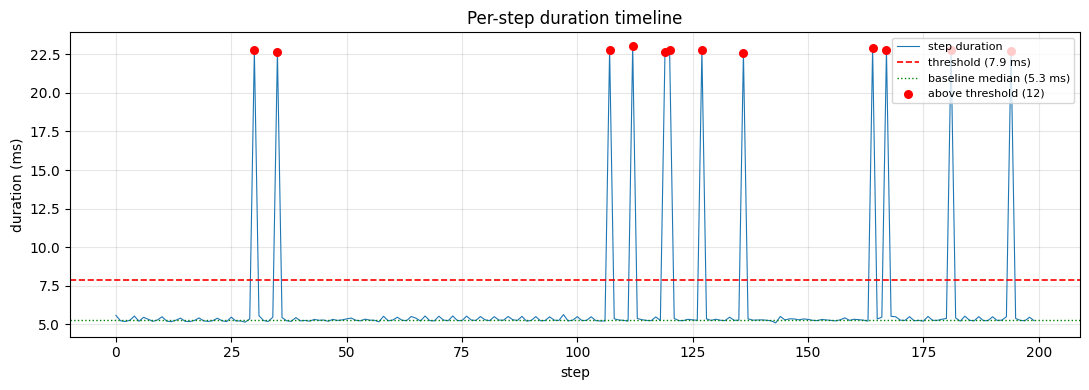

In [3]:
# Tiny warmup so CUDA context init / autotune doesn't show up as a giant outlier.
for _ in range(5):
    train_step()
torch.cuda.synchronize()

DIAGNOSTIC_STEPS = 200
step_durs_ms: list[float] = []
for _ in range(DIAGNOSTIC_STEPS):
    t0 = time.perf_counter()
    train_step()
    torch.cuda.synchronize()
    step_durs_ms.append((time.perf_counter() - t0) * 1000.0)

baseline_median = statistics.median(step_durs_ms)
THRESHOLD_MULTIPLIER = 1.5
threshold_ms = baseline_median * THRESHOLD_MULTIPLIER
print(f"baseline median: {baseline_median:.2f} ms   threshold (1.5x): {threshold_ms:.2f} ms")

fig, ax = plt.subplots(figsize=(11, 4))
x = list(range(len(step_durs_ms)))
above_x = [i for i, d in enumerate(step_durs_ms) if d > threshold_ms]
above_y = [step_durs_ms[i] for i in above_x]
ax.plot(x, step_durs_ms, lw=0.8, color="#1f77b4", label="step duration")
ax.axhline(threshold_ms, color="red", lw=1.2, ls="--", label=f"threshold ({threshold_ms:.1f} ms)")
ax.axhline(baseline_median, color="green", lw=1.0, ls=":", label=f"baseline median ({baseline_median:.1f} ms)")
ax.scatter(above_x, above_y, color="red", s=30, zorder=5, label=f"above threshold ({len(above_x)})")
ax.set_xlabel("step")
ax.set_ylabel("duration (ms)")
ax.set_title("Per-step duration timeline")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Points above the threshold (red) sit well above the baseline. If your timeline shows a noisy band with no clear gap between baseline and the high points, the workload is jittery rather than anomalous and threshold capture won't help much.

## 4  Per-step profiler flush

We want each saved trace to contain *only* the anomalous step's events — no surrounding healthy steps. The way to do this is to make the profiler flush its buffer on **every** `prof.step()` boundary, then let the handler decide whether to keep the file.

`schedule(wait=0, warmup=0, active=1)` returns `RECORD_AND_SAVE` every step, which flushes the buffer to `on_trace_ready` and resets on every `prof.step()`. Each handler call sees exactly one step's events. PyTorch will print a `Profiler won't be using warmup` warning — safe to ignore, we already warmed up CUDA in §3. (See the [profiling guide](./torch_profiling_guide.ipynb) for the `schedule()` factory's general form.)

In [4]:
sched = schedule(wait=0, warmup=0, active=1)

/tmp/ipykernel_4984/2113088922.py:1: UserWarning: Profiler won't be using warmup, this can skew profiler results
  sched = schedule(wait=0, warmup=0, active=1)


## 5  Filter in the handler

The handler decides whether the just-finished step is worth keeping. At the end of each loop iteration we push `(step, dur)` onto a FIFO. The handler pops one entry per invocation and writes to disk only if the duration exceeds the threshold. Non-anomalous steps fall through — their events were flushed from the in-memory buffer and discarded by the profiler, never serialized to JSON, never touch disk.

The queue is effectively single-entry in steady state (one push per step, one pop per handler call). It still pays to make it explicit: PyTorch fires the handler once more on profiler shutdown to flush residual events, and at that point the queue is empty so the handler returns early.

In [5]:
OUTPUT_DIR = Path("./anomaly_traces")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
for old in OUTPUT_DIR.glob("anomaly_*.json"):
    old.unlink()
for old in OUTPUT_DIR.glob("anomaly_*.xlsx"):
    old.unlink()

step_info_queue: list[tuple[int, float]] = []
saved_files: list[Path] = []


def trace_handler(prof):
    if not step_info_queue:
        return
    step, duration_ms = step_info_queue.pop(0)
    if duration_ms <= threshold_ms:
        return  # not anomalous → discard, nothing written to disk
    out = OUTPUT_DIR / f"anomaly_step{step:05d}_dur{duration_ms:.1f}ms.json"
    prof.export_chrome_trace(str(out))
    saved_files.append(out)
    print(f"    saved: {out.name}  ({out.stat().st_size / 1024:.1f} KB)")

## 6  The always-on profiling loop

Generic training loop: time each step, push `(step, dur)`, call `prof.step()`. Detection is purely duration-based — we have no idea which steps will be anomalous. We use `activities=[ProfilerActivity.CUDA]` only (no CPU op decode, no Python stacks) to keep per-step overhead small enough for always-on profiling. The handler fires synchronously inside `prof.step()` and either writes the just-finished step's trace or returns silently.

In [6]:
NUM_STEPS = 200
print(f"Running {NUM_STEPS} steps with always-on CUDA-only profiling, threshold={threshold_ms:.2f} ms\n")

loop_start = time.perf_counter()
with profile(
    activities=[ProfilerActivity.CUDA],
    schedule=sched,
    on_trace_ready=trace_handler,
    record_shapes=False,
    with_stack=False,
) as prof:
    for global_step in range(NUM_STEPS):
        step_start = time.perf_counter()
        train_step()
        torch.cuda.synchronize()
        dur = (time.perf_counter() - step_start) * 1000.0
        step_info_queue.append((global_step, dur))
        prof.step()

elapsed = time.perf_counter() - loop_start
print(f"\nWall time: {elapsed:.2f} s ({elapsed * 1000 / NUM_STEPS:.2f} ms/step including profiler overhead)")

Running 200 steps with always-on CUDA-only profiling, threshold=7.90 ms



/opt/venv/lib/python3.12/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
[W518 16:28:12.376799491 collection.cpp:1148] Warning: ROCTracer produced duplicate flow start: 2 (function operator())


    saved: anomaly_step00020_dur23.4ms.json  (830.6 KB)


    saved: anomaly_step00043_dur23.0ms.json  (830.6 KB)
    saved: anomaly_step00044_dur23.1ms.json  (830.6 KB)
    saved: anomaly_step00050_dur23.2ms.json  (830.6 KB)


    saved: anomaly_step00061_dur23.1ms.json  (830.6 KB)
    saved: anomaly_step00068_dur23.3ms.json  (830.6 KB)


...

    saved: anomaly_step00105_dur23.0ms.json  (830.6 KB)


    saved: anomaly_step00128_dur23.1ms.json  (830.6 KB)


    saved: anomaly_step00155_dur23.2ms.json  (830.6 KB)
    saved: anomaly_step00166_dur23.4ms.json  (830.6 KB)
    saved: anomaly_step00168_dur23.0ms.json  (830.6 KB)


    saved: anomaly_step00169_dur23.2ms.json  (830.6 KB)


    saved: anomaly_step00197_dur23.3ms.json  (832.7 KB)

Wall time: 2.68 s (13.42 ms/step including profiler overhead)


## 7  Putting the anomaly trace through TraceLens

Each saved file contains exactly one anomalous step's CUDA events — small, focused, ready to drop into [Perfetto](https://ui.perfetto.dev/) or feed to the TraceLens [perf-report generator](../generate_perf_report.md), which summarises any PyTorch JSON trace into tables. For our CUDA-only traces it emits `gpu_timeline` and `kernel_summary` (the op-level sheets need CPU events, which we don't have). Pass `include_unlinked_kernels=True` so the GPU timeline counts kernels that have no host call-stack to link against.

In [7]:
from TraceLens.Reporting.generate_perf_report_pytorch import generate_perf_report_pytorch

target_trace = saved_files[0]
print(f"Generating perf report for: {target_trace.name}\n")

dfs = generate_perf_report_pytorch(
    profile_json_path=str(target_trace),
    include_unlinked_kernels=True,
    kernel_summary=True,
)
print(f"\nSheets returned: {list(dfs.keys())}")

Generating perf report for: anomaly_step00020_dur23.4ms.json

Building tree with add_python_func=False
Building CPU op tree with add_python_func=False
Detected GPU-only trace. Skipping CPU-dependent analysis and generating only GPU timeline and kernel summary.
DataFrames successfully written to anomaly_traces/anomaly_step00020_dur23.4ms_perf_report.xlsx

Sheets returned: ['gpu_timeline', 'kernel_summary']


### GPU timeline

Compute vs idle vs comm vs memcpy breakdown for the anomalous step. A compute-heavy anomaly points at extra work; high idle points at host stalls; a comm anomaly points at a slow collective.

In [8]:
df_timeline = dfs["gpu_timeline"].copy()
df_timeline["time ms"] = df_timeline["time ms"].round(3)
df_timeline["percent"] = df_timeline["percent"].round(2)
df_timeline

,type,time ms,percent
0,computation_time,22.479,96.92
1,exposed_comm_time,0.000,0.00
2,exposed_memcpy_time,0.000,0.00
3,busy_time,22.479,96.92
4,idle_time,0.713,3.08
5,total_time,23.192,100.00
6,total_comm_time,0.000,0.00
7,total_memcpy_time,0.000,0.00


### Kernel summary

Top kernels by total time within the anomalous step. Names get truncated for display.

In [9]:
# "\u00b5" is the micro sign (µ); the TraceLens output uses it in column names.
rename_map = {
    "Kernel duration (\u00b5s)_sum": "total (\u00b5s)",
    "Kernel duration (\u00b5s)_count": "count",
    "Kernel duration (\u00b5s)_mean": "mean (\u00b5s)",
    "Percent of total time (%)": "% total",
}
df_kern = (
    dfs["kernel_summary"]
    .sort_values("Kernel duration (\u00b5s)_sum", ascending=False)
    .head(10)
    .copy()
)
df_kern["kernel (truncated)"] = df_kern["Kernel name"].str.slice(0, 60) + "..."
df_kern_view = (
    df_kern[["kernel (truncated)", *rename_map.keys()]]
    .rename(columns=rename_map)
    .round({"total (\u00b5s)": 1, "mean (\u00b5s)": 2, "% total": 2})
)
df_kern_view

,kernel (truncated),total (µs),count,mean (µs),% total
0,Cijk_Ailk_Bljk_BBS_BH_Bias_HA_S_SAV_UserArgs_M...,17453.8,2,8726.92,75.26
1,void at::native::batch_norm_backward_kernel<c1...,560.9,20,28.05,2.42
2,void at::native::batch_norm_collect_statistics...,366.4,20,18.32,1.58
3,batched_transpose_16x64_pack_1x4_ediv_1x2_half...,354.5,73,4.86,1.53
4,igemm_wrw_gtcx2_nhwc_bf16_bx0_ex1_bt256x128x16...,292.0,10,29.20,1.26
5,SubTensorOpWithCastTensor1d...,235.8,42,5.61,1.02
6,SubTensorOpWithScalar1d...,202.2,52,3.89,0.87
7,igemm_bwd_gtcx2_nhwc_bf16_bx0_ex1_bt32x128x32_...,187.4,7,26.76,0.81
8,batched_transpose_64x64_pack_4x4_ediv_4x4_half...,175.0,30,5.83,0.75
9,void at::native::batch_norm_transform_input_ke...,158.1,20,7.90,0.68


Because the trace only contains the anomalous step, the kernels responsible sit at the very top — small `count`, large `sum`. Our synthetic 8192×8192 bf16 matmul lights up exactly that way. The same data is also saved as `.xlsx`:

In [10]:
xlsx_path = target_trace.with_name(target_trace.stem + "_perf_report.xlsx")
if xlsx_path.exists():
    print(f"Excel report: {xlsx_path}  ({xlsx_path.stat().st_size / 1024:.1f} KB)")
else:
    print(f"Excel report not found at {xlsx_path}")

Excel report: anomaly_traces/anomaly_step00020_dur23.4ms_perf_report.xlsx  (12.6 KB)


## Recap

- Time each step with `time.perf_counter()` + a trailing `cuda.synchronize()`
- One short pass to set `threshold = 1.5 × median`
- Schedule that always returns `RECORD_AND_SAVE` → buffer flushes every step
- Trace handler pops `(step, dur)` from a single-entry FIFO and writes to disk only if `dur > threshold`
- Always-on profiler with CUDA-only activities; training loop is generic and unaware of detection

Once you have per-anomaly trace files, run them through `generate_perf_report_pytorch` (or the CLI `TraceLens_generate_perf_report_pytorch`). For deeper analysis see the [profiling analysis blog](./torch_profiling_analysis.md).